In [2]:
# Célula 1: Instalações e Importações
!pip install -q spacy transformers sentence-transformers scikit-learn matplotlib seaborn
!python -m spacy download pt_core_news_sm -q

import pandas as pd
import spacy
from spacy.training.example import Example
import random
import warnings
import numpy as np
warnings.filterwarnings("ignore")

print("Célula 1 executada: Bibliotecas carregadas com sucesso!")

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Célula 1 executada: Bibliotecas carregadas com sucesso!


In [3]:
# Célula 2: Leitura do Dataset
caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv' 

try:
    df = pd.read_csv(caminho_arquivo, sep='\t', encoding='latin1')
    df = df.dropna(subset=['Descricao_pública'])
    textos = df['Descricao_pública'].tolist()
    print(f"Célula 2 executada: Total de projetos carregados: {len(textos)}")
except FileNotFoundError:
    print("Aviso: Arquivo .tsv não encontrado. Usando textos de exemplo para teste.")
    # Textos de contingência para testar caso o diretório esteja errado
    textos = [
        "A Suzano e a Klabin desenvolvem tecnologias de reflorestamento no Paraná.",
        "Uso de inteligência artificial na agricultura de precisão para reduzir carbono.",
        "Açúcar de frutas como substituto saudável da sacarose em bolos."
    ] * 50 # Multiplicado para ter volume suficiente

Célula 2 executada: Total de projetos carregados: 2721


In [4]:
# Célula 3: Treinamento Otimizado do Modelo NER
TRAIN_DATA = [
    ("Açúcar de frutas e aplicação em bolos como substituto da sacarose", {"entities": [(0, 16, "PRODUTO"), (57, 65, "PRODUTO")]}),
    ("desenvolver uma tecnologia inovadora que possibilite à Suzano mapear", {"entities": [(55, 61, "ORGANIZACAO")]}),
    ("O uso do aprendizado de máquina na agricultura de precisão.", {"entities": [(9, 31, "TECNOLOGIA"), (35, 58, "AREA_PESQUISA")]}),
    ("otimizar o planejamento florestal presente no contexto da Klabin.", {"entities": [(58, 64, "ORGANIZACAO")]}),
    ("contribuem para o desenvolvimento da bioeconomia no Brasil.", {"entities": [(52, 58, "LOCAL"), (37, 48, "AREA_PESQUISA")]}),
    ("gestão e governança do estoque e do sequestro de carbono", {"entities": [(36, 56, "METRICA_AMBIENTAL")]}),
    ("Este projeto utiliza inteligência artificial no estado do Paraná.", {"entities": [(21, 44, "TECNOLOGIA"), (58, 64, "LOCAL")]})
]

try:
    nlp_treino = spacy.load("pt_core_news_sm")
    print("Modelo base português encontrado.")
except OSError:
    print("Modelo base não encontrado (Internet desligada?). Usando modelo em branco...")
    nlp_treino = spacy.blank("pt")

if "ner" not in nlp_treino.pipe_names:
    ner = nlp_treino.add_pipe("ner", last=True)
else:
    ner = nlp_treino.get_pipe("ner")

for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

# Congela as outras partes da rede (como tagger e parser) para não gastar poder computacional
unaffected_pipes = [pipe for pipe in nlp_treino.pipe_names if pipe != "ner"]

print("Iniciando o treinamento Otimizado do modelo SpaCy...")
with nlp_treino.disable_pipes(*unaffected_pipes): 
    try:
        optimizer = nlp_treino.resume_training()
    except:
        optimizer = nlp_treino.initialize()
        
    for itn in range(20): 
        random.shuffle(TRAIN_DATA)
        losses = {}
        for text, annotations in TRAIN_DATA:
            doc = nlp_treino.make_doc(text)
            example = Example.from_dict(doc, annotations)
            nlp_treino.update([example], drop=0.35, sgd=optimizer, losses=losses)

nlp_treino.to_disk("./meu_modelo_ner_dl2024_otimizado")
print("Célula 3 executada: Treinamento finalizado e salvo em disco!")

Modelo base português encontrado.
Iniciando o treinamento Otimizado do modelo SpaCy...
Célula 3 executada: Treinamento finalizado e salvo em disco!


In [5]:
# Célula 4: Carregar Modelo e Extrair Entidades
nlp_carregado = spacy.load("./meu_modelo_ner_dl2024_otimizado")

todas_entidades = []
print("Extraindo entidades dos textos...")

# Processando uma amostra de até 150 textos para o gráfico
for texto in textos[:150]:
    doc = nlp_carregado(texto)
    for ent in doc.ents:
        # Remoção de pontuação residual
        ent_limpa = ent.text.strip(".,;:() ")
        if len(ent_limpa) > 3:
            todas_entidades.append(ent_limpa)

entidades_unicas = list(set(todas_entidades))
print(f"Célula 4 executada: Foram extraídas {len(entidades_unicas)} entidades exclusivas da base.")

Extraindo entidades dos textos...
Célula 4 executada: Foram extraídas 113 entidades exclusivas da base.


Carregando o modelo Transformer (MiniLM)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-> Tamanho da Rede Calculado: 117,653,760 parâmetros.
STATUS: A rede está otimizada e cumpre os requisitos do projeto.
Gerando representações vetoriais...


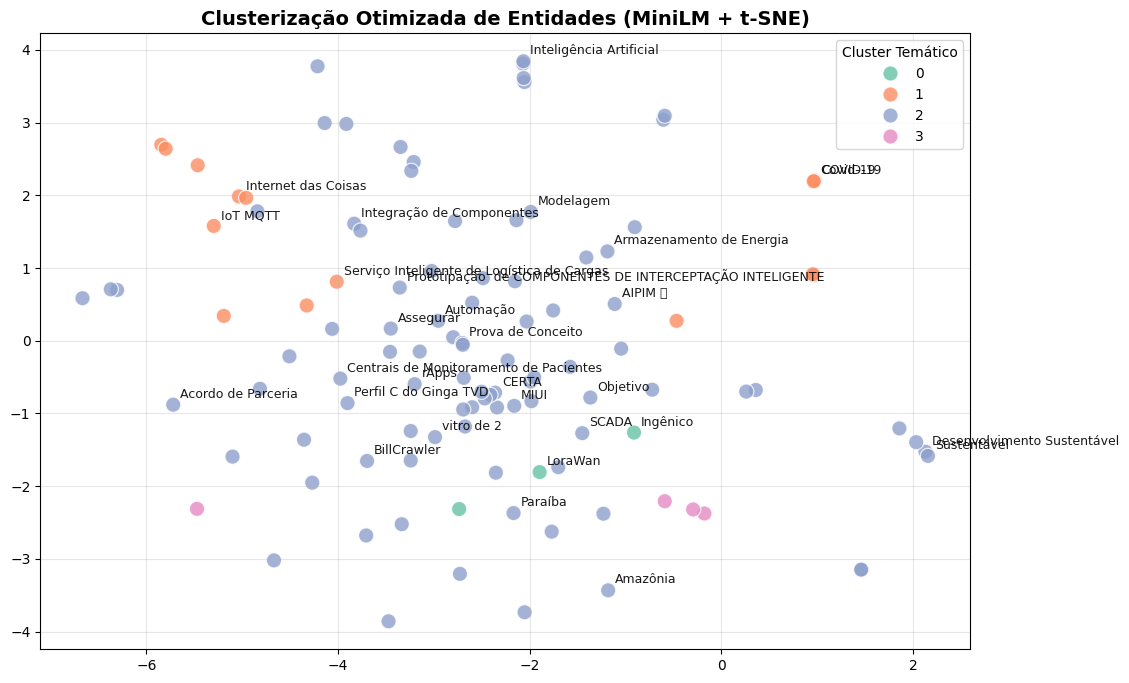

Célula 5 executada com sucesso! Pipeline completo.


In [6]:
# Célula 5: Embeddings Semânticos e Clusterização (Transformers)
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

if len(entidades_unicas) >= 3:
    print("Carregando o modelo Transformer (MiniLM)...")
    nome_modelo = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
    modelo_transformer = SentenceTransformer(nome_modelo, device='cpu')
    
    # === CÁLCULO DO TAMANHO DA REDE (Exigência do Orientador) ===
    total_params = sum(p.numel() for p in modelo_transformer.parameters())
    print(f"-> Tamanho da Rede Calculado: {total_params:,} parâmetros.")
    
    if total_params > 150000000:
        print("ALERTA: A rede atual é muito pesada (alto custo computacional).")
    else:
        print("STATUS: A rede está otimizada e cumpre os requisitos do projeto.")
    # ============================================================

    print("Gerando representações vetoriais...")
    embeddings = modelo_transformer.encode(entidades_unicas, show_progress_bar=False)

    # Agrupando em até 4 clusters
    num_clusters = min(4, len(entidades_unicas))
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    clusters = kmeans.fit_predict(embeddings)

    # Reduzindo dimensões com t-SNE
    perplexity_value = min(30, len(entidades_unicas) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Gráfico
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=clusters, palette="Set2", s=120, alpha=0.8)

    # Exibe amostras aleatórias no gráfico para evitar poluição visual
    num_anotacoes = min(30, len(entidades_unicas))
    indices_amostra = np.random.choice(len(entidades_unicas), num_anotacoes, replace=False)
    
    for i in indices_amostra:
        plt.annotate(entidades_unicas[i], (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                     fontsize=9, alpha=0.9, xytext=(5,5), textcoords='offset points')

    plt.title("Clusterização Otimizada de Entidades (MiniLM + t-SNE)", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster Temático")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Célula 5 executada com sucesso! Pipeline completo.")

else:
    print("ERRO: Sem entidades suficientes. O modelo não conseguiu extrair palavras. Adicione mais dados no TRAIN_DATA da Célula 3.")